In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.ensemble import IsolationForest

# Generate synthetic data
np.random.seed(42)
X_inliers = 0.3 * np.random.randn(100, 2) + np.array([2, 2])
X_outliers = np.random.uniform(low=-4, high=4, size=(20, 2))
X = np.concatenate([X_inliers, X_outliers], axis=0)

df = pd.DataFrame(X, columns=['Feature_1', 'Feature_2'])
display(df.head())

,Feature_1,Feature_2
0,2.149014,1.958521
1,2.194307,2.456909
2,1.929754,1.929759
3,2.473764,2.230230
4,1.859158,2.162768


In [2]:
# Train Isolation Forest model
model = IsolationForest(contamination=0.15, random_state=42)
model.fit(df)

# Predict outliers (1 for inliers, -1 for outliers)
df['outlier'] = model.predict(df)
display(df.head())

,Feature_1,Feature_2,outlier
0,2.149014,1.958521,1
1,2.194307,2.456909,1
2,1.929754,1.929759,1
3,2.473764,2.230230,1
4,1.859158,2.162768,1


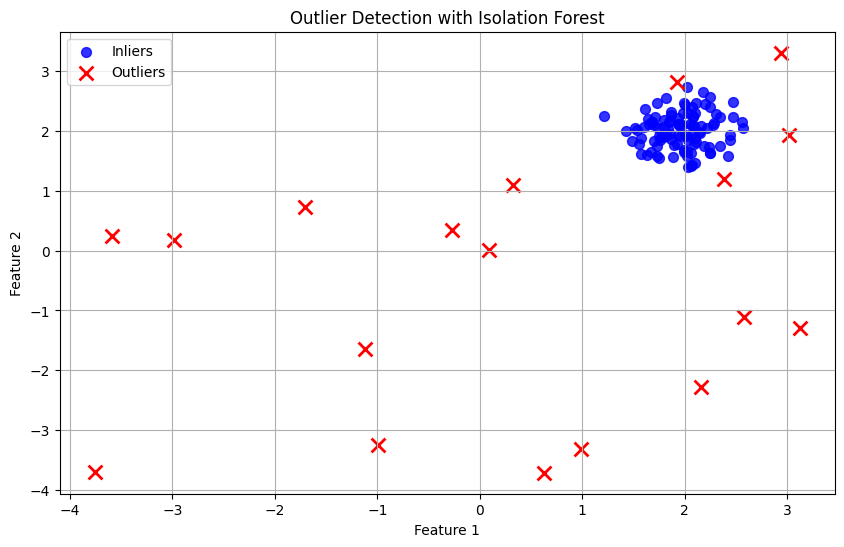

In [3]:
# Visualize the results
fig = plt.figure(figsize=(10, 6))
inliers = df[df['outlier'] == 1]
outliers = df[df['outlier'] == -1]

plt.scatter(inliers['Feature_1'], inliers['Feature_2'], c='blue', label='Inliers', s=50, alpha=0.8)
plt.scatter(outliers['Feature_1'], outliers['Feature_2'], c='red', label='Outliers', s=100, marker='x', linewidth=2)
plt.title('Outlier Detection with Isolation Forest')
plt.xlabel('Feature 1')
plt.ylabel('Feature 2')
plt.legend()
plt.grid(True)
plt.show()